# Actividad 3
En este análisis se construye un modelo de regresión lineal para predecir el número de carreras en función al número de bateos, utilizando datos sacados directamente de Espn.

El primer paso es cargar todas las librerías que utilizaremos tanto para calculos, como para gráficas o visualizaciones.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Carga de datos
Aquí cargamos nuestro csv y nos preparamos para limpiarlo.

In [18]:
file_name = "Datos/mlb_runs.csv"

if os.path.exists(file_name):
  df = pd.read_csv(file_name)
else:
  raise FileNotFoundError("El archivo no fue encontrado")

df.head()

,Ranking,Nombre,Equipo,POS,GP,AB,R,H,AVG,2B,...,HR,RBI,TB,BB,K,SB,OBP,SLG,OPS,WAR
0,1,Andy Pages,LAD,CF,18,66,10,27,0.409,4,...,5,20,46,4,18,3,0.451,0.697,1.148,1.6
1,2,Yandy Diaz,TB,1B,18,70,11,26,0.371,2,...,3,16,39,8,8,1,0.463,0.557,1.021,1.1
2,2,CJ Abrams,WSH,SS,18,62,12,23,0.371,3,...,6,19,44,9,10,4,0.481,0.710,1.190,1.2
3,4,Chandler Simpson,TB,LF,18,69,9,24,0.348,0,...,0,4,28,3,5,7,0.375,0.406,0.781,0.8
4,14,Nico Hoerner,CHC,2B,19,76,13,26,0.342,7,...,3,20,42,9,9,6,0.420,0.553,0.973,1.5


## Limpieza de los datos
Durante este proceso identificamos los valores nulos y se hacen ajustes para realizar un mejor análisis del dataset.

In [19]:
print("Valores nulos:\n")
print(df.isnull().sum())

df = df[['AB', 'R']]

df.head()

Valores nulos:

Ranking    0
Nombre     0
Equipo     0
POS        0
GP         0
AB         0
R          0
H          0
AVG        0
2B         0
3B         0
HR         0
RBI        0
TB         0
BB         0
K          0
SB         0
OBP        0
SLG        0
OPS        0
WAR        0
dtype: int64


,AB,R
0,66,10
1,70,11
2,62,12
3,69,9
4,76,13


## Análisis exploratorio
Se calcula el coeficiente de correlación de Pearson entre las variables AB(bateos) y R(Carreras), con el objetivo de evaluar la relación entre ambas.

In [20]:
correlation = df['AB'].corr(df['R'])

print("Correlación de Pearson: ", correlation)

Correlación de Pearson:  0.34604520988865034


## División de datos
El dataset se divide en dos conjuntos:

- Entrenamiento: Utilizado para ajustar el modelo
- Prueba: Utilizado para evaluar el desempeño del modelo

In [21]:
x = df[['AB']]
y = df['R']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

print("Datos de entrenamiento:", len(x_train))
print("Datos de prueba:", len(x_test))

Datos de entrenamiento: 153
Datos de prueba: 39


## Construcción del modelo

Se implementa el modelo de regresión líneal que consiste de:

- Variable independiente: Número de bateos
- Variable dependiente: Número de carreras

In [22]:
model = LinearRegression()
model.fit(x_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Predicciones

Una vez entrenado el modelo, se generan las predicciones sobre el conjunto de prueba, lo que representa los valores estimados de carreras en función de los bateos.

In [23]:
y_pred = model.predict(x_test)
y_pred[:5]

array([10.42169379, 10.16181629, 10.42169379,  9.12230629,  9.51212254])

## Relación entre bateos y carreras
Se presenta la gráfica que muestra la relación entre los bateos y las carreras, junto con la línea de regresión obtenida, lo que nos permite observar la tendencia general entre ambas.

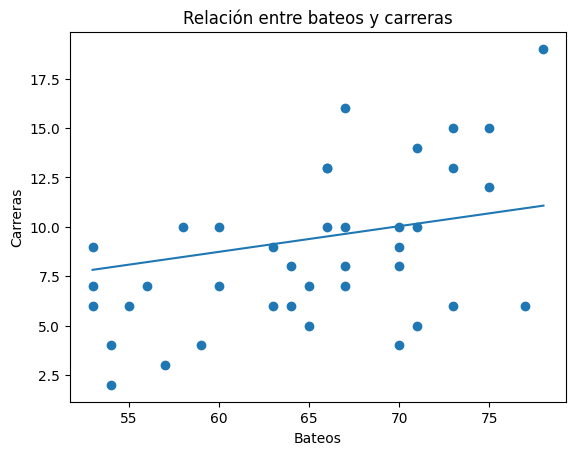

In [24]:
sorted_idx = x_test['AB'].argsort()
x_test_sorted = x_test.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure()
plt.scatter(x_test, y_test)
plt.plot(x_test_sorted, y_pred_sorted)

plt.xlabel("Bateos")
plt.ylabel("Carreras")
plt.title("Relación entre bateos y carreras")

plt.show()

## Carreras reales vs carreras predichas
Se compara el valor real de las carreras con el valor de las carreras predichas para comprobar la precisión del modelo.

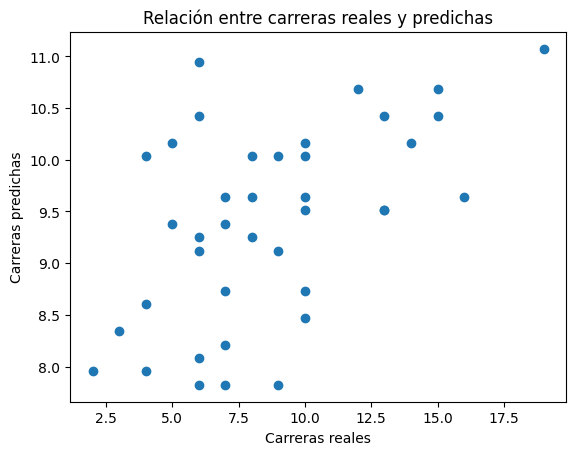

In [25]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Carreras reales")
plt.ylabel("Carreras predichas")
plt.title("Relación entre carreras reales y predichas")

plt.show()

## Evaluación del modelo
Se evalua el desempeño del modelo usando métricas como:
- Error absoluto medio
- Error cuadrático medio
- Raíz del error cuadrático medio
- Coeficiente de determinación

In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo:\n")
print("Error absoluto medio", mae)
print("Error cuadrático medio", mse)
print("Raíz del error cuadrático medio", rmse)
print("Coeficiente de determinación", r2)

Evaluación del modelo:

Error absoluto medio 2.8935495313182216
Error cuadrático medio 12.26453589204384
Raíz del error cuadrático medio 3.502075940359352
Coeficiente de determinación 0.16714174962949013


## Conclusión
Una vez ya obtenidos todos los datos y evaluaciones vemos que se logra la relación general entre el número de bateos y las carreras, sin embargo, las predicciones no parecen ser tan precisas.

In [27]:
print("Conclusión:\n")

if correlation > 0:
  print("Existe una correlación positiva entre los bateos y las carreras")
else:
  print("Existe una correlación negativa entre los bateos y las carreras")

if r2 > 0.7:
  print("El modelo tiene buen ajuste")
elif r2 > 0.4:
  print("El modelo tiene un ajuste moderado")
else:
  print("El modelo tiene bajo nivel predictivo")

Conclusión:

Existe una correlación positiva entre los bateos y las carreras
El modelo tiene bajo nivel predictivo
